In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
test.shape

(1000, 21)

In [5]:
phishing = pd.read_csv("../Phishing_Legitimate_full.csv")

In [6]:
phishing.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  10000 non-null  int64  
 1   NumDots                             10000 non-null  int64  
 2   SubdomainLevel                      10000 non-null  int64  
 3   PathLevel                           10000 non-null  int64  
 4   UrlLength                           10000 non-null  int64  
 5   NumDash                             10000 non-null  int64  
 6   NumDashInHostname                   10000 non-null  int64  
 7   AtSymbol                            10000 non-null  int64  
 8   TildeSymbol                         10000 non-null  int64  
 9   NumUnderscore                       10000 non-null  int64  
 10  NumPercent                          10000 non-null  int64  
 11  NumQueryComponents                  10000 non-null  i

In [7]:
phishing.isnull().sum()

id                                    0
NumDots                               0
SubdomainLevel                        0
PathLevel                             0
UrlLength                             0
NumDash                               0
NumDashInHostname                     0
AtSymbol                              0
TildeSymbol                           0
NumUnderscore                         0
NumPercent                            0
NumQueryComponents                    0
NumAmpersand                          0
NumHash                               0
NumNumericChars                       0
NoHttps                               0
RandomString                          0
IpAddress                             0
DomainInSubdomains                    0
DomainInPaths                         0
HttpsInHostname                       0
HostnameLength                        0
PathLength                            0
QueryLength                           0
DoubleSlashInPath                     0


In [8]:
phishing.drop("id", axis=1, inplace=True)

In [9]:
phishing.duplicated().sum()

np.int64(419)

In [10]:
phishing.drop_duplicates(inplace=True)

In [11]:
phishing.nunique()

NumDots                                 17
SubdomainLevel                          13
PathLevel                               18
UrlLength                              226
NumDash                                 25
NumDashInHostname                       10
AtSymbol                                 2
TildeSymbol                              2
NumUnderscore                           16
NumPercent                              14
NumQueryComponents                      19
NumAmpersand                            16
NumHash                                  2
NumNumericChars                         82
NoHttps                                  2
RandomString                             2
IpAddress                                2
DomainInSubdomains                       2
DomainInPaths                            2
HttpsInHostname                          1
HostnameLength                          74
PathLength                             147
QueryLength                            164
DoubleSlash

In [12]:
# sns.pairplot(phishing)

<Axes: ylabel='PathLength'>

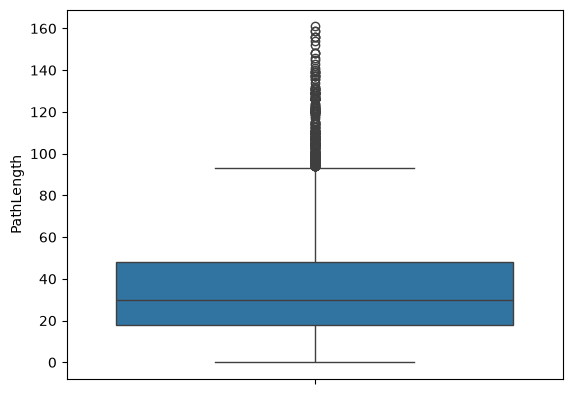

In [13]:
sns.boxplot(phishing["PathLength"])

<Axes: xlabel='PathLength', ylabel='Count'>

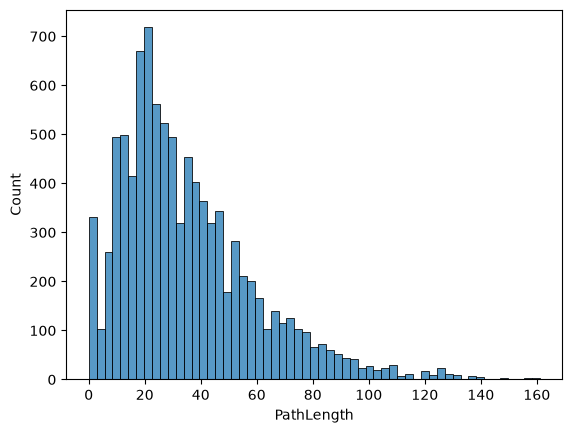

In [14]:
sns.histplot(phishing["PathLength"])

<Axes: xlabel='PathLength', ylabel='Density'>

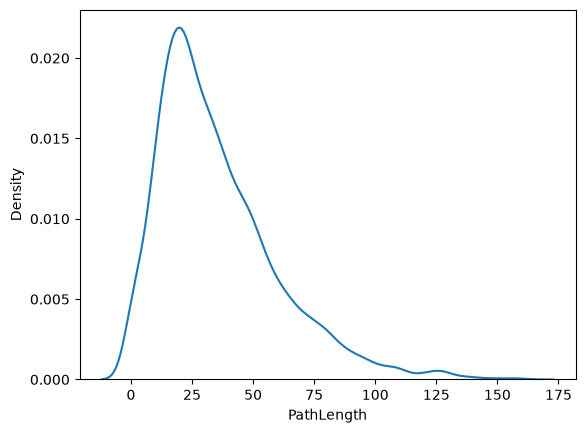

In [15]:
sns.kdeplot(phishing["PathLength"])

In [16]:
phishing.skew()

NumDots                                3.300980
SubdomainLevel                         4.239341
PathLevel                              1.276483
UrlLength                              1.682543
NumDash                                2.760323
NumDashInHostname                      6.675292
AtSymbol                              56.494834
TildeSymbol                            8.923677
NumUnderscore                          5.435449
NumPercent                            14.030087
NumQueryComponents                     5.047751
NumAmpersand                           6.321729
NumHash                               20.799946
NumNumericChars                        3.691977
NoHttps                               -9.736803
RandomString                          -0.072912
IpAddress                              7.594344
DomainInSubdomains                     7.671230
DomainInPaths                          0.284907
HttpsInHostname                        0.000000
HostnameLength                         3

In [17]:
phishing["HttpsInHostname"].value_counts()

HttpsInHostname
0    9581
Name: count, dtype: int64

In [18]:
phishing.drop("HttpsInHostname", axis=1, inplace=True)

In [19]:
phishing.shape

(9581, 48)

In [20]:
phishing.corr()

,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
NumDots,1.000000,0.499645,0.070382,0.281173,-0.205321,0.092699,0.011985,0.098076,0.042746,0.025179,...,-0.120186,0.050674,-0.008395,-0.325075,-0.148687,0.043420,0.032709,0.033482,-0.149584,0.296978
SubdomainLevel,0.499645,1.000000,-0.003598,0.096348,-0.056530,0.221762,-0.005835,0.007665,-0.017766,-0.003973,...,-0.003197,0.034438,-0.004683,-0.644643,-0.075567,0.046394,-0.038298,0.079130,-0.003529,0.024308
PathLevel,0.070382,-0.003598,1.000000,0.381193,0.090186,0.003268,-0.005739,0.107636,0.019494,-0.042768,...,-0.007093,-0.022025,0.005071,-0.016508,-0.393307,-0.010664,0.034542,0.060373,-0.089540,0.221077
UrlLength,0.281173,0.096348,0.381193,1.000000,0.437941,0.082297,-0.003384,0.041372,0.358551,0.192076,...,0.026122,-0.046599,-0.030009,-0.132472,-0.803129,-0.001936,-0.030096,-0.009167,0.149695,-0.088229
NumDash,-0.205321,-0.056530,0.090186,0.437941,1.000000,0.093502,-0.010371,-0.027876,-0.055222,-0.018635,...,0.224213,-0.062640,-0.003448,-0.015262,-0.470578,-0.139195,-0.084411,-0.128356,0.188722,-0.375612
NumDashInHostname,0.092699,0.221762,0.003268,0.082297,0.093502,1.000000,-0.004331,-0.013303,-0.028155,-0.019646,...,-0.005912,-0.007993,-0.001741,-0.310202,-0.068449,0.060479,0.028937,0.040743,-0.077451,0.132974
AtSymbol,0.011985,-0.005835,-0.005739,-0.003384,-0.010371,-0.004331,1.000000,-0.001959,-0.005220,0.007158,...,-0.012671,-0.003176,-0.003127,0.002822,-0.007715,-0.006776,-0.003993,0.011826,0.013136,-0.016954
TildeSymbol,0.098076,0.007665,0.107636,0.041372,-0.027876,-0.013303,-0.001959,1.000000,-0.020884,-0.013339,...,-0.034906,-0.008892,-0.019559,0.013416,-0.027720,0.017567,0.019519,0.051965,-0.006208,0.094546
NumUnderscore,0.042746,-0.017766,0.019494,0.358551,-0.055222,-0.028155,-0.005220,-0.020884,1.000000,0.060900,...,-0.010332,-0.018039,-0.019911,-0.006460,-0.262715,0.019711,-0.051203,-0.045232,0.094327,-0.090962
NumPercent,0.025179,-0.003973,-0.042768,0.192076,-0.018635,-0.019646,0.007158,-0.013339,0.060900,1.000000,...,-0.021327,-0.011226,-0.006895,0.003883,-0.129742,0.022464,-0.000362,0.019561,0.033183,-0.065738


<Axes: >

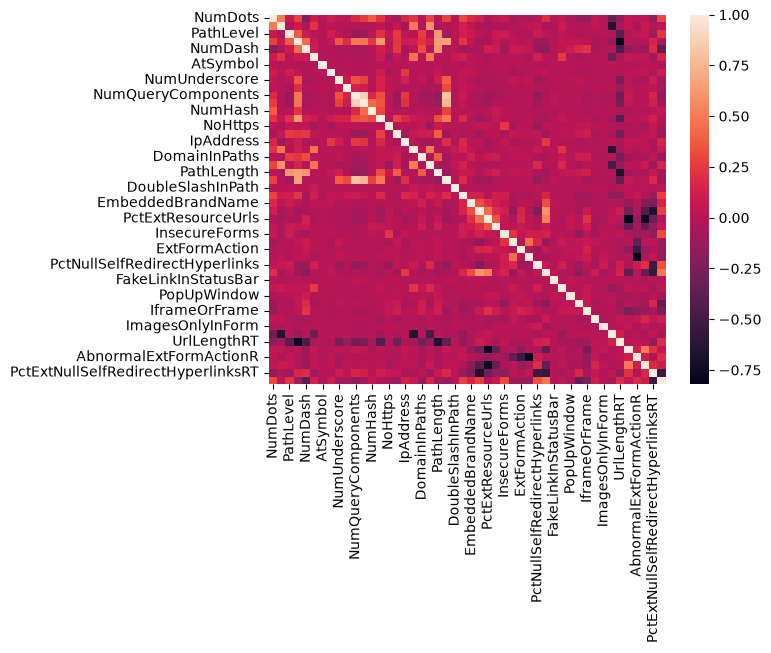

In [21]:
sns.heatmap(phishing.corr())

In [22]:
x = phishing.drop("CLASS_LABEL", axis=1)

In [23]:
y = phishing["CLASS_LABEL"]

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

In [25]:
x_train.shape

(7664, 47)

In [26]:
x_test.shape

(1917, 47)

In [27]:
dtc = DecisionTreeClassifier(max_depth=8, min_samples_split=20, min_samples_leaf=10, random_state=42)
dtc.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [28]:
y_pred = dtc.predict(x_test)

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score

- Model Evaluation (Testing)

In [30]:
accu = accuracy_score(y_test, y_pred) * 100
accu

97.0266040688576

In [31]:
rel_score = recall_score(y_test, y_pred) * 100
rel_score

97.61904761904762

In [32]:
class_rept = classification_report(y_test, y_pred, output_dict=True)
class_rept

{'0': {'precision': 0.9775510204081632,
  'recall': 0.9647532729103726,
  'f1-score': 0.9711099847947289,
  'support': 993.0},
 '1': {'precision': 0.9626467449306296,
  'recall': 0.9761904761904762,
  'f1-score': 0.969371305749597,
  'support': 924.0},
 'accuracy': 0.9702660406885759,
 'macro avg': {'precision': 0.9700988826693964,
  'recall': 0.9704718745504244,
  'f1-score': 0.9702406452721629,
  'support': 1917.0},
 'weighted avg': {'precision': 0.9703671129792425,
  'recall': 0.9702660406885759,
  'f1-score': 0.9702719360531002,
  'support': 1917.0}}

In [33]:
conf_matr = confusion_matrix(y_test, y_pred)
conf_matr

array([[958,  35],
       [ 22, 902]])

- Underfitting & Overfitting

In [34]:
y_train_pred = dtc.predict(x_train)

train_acc = accuracy_score(y_train, y_train_pred)
test_accuracy = dtc.score(x_test, y_test)

print("Training accuracy: ", train_acc)
print("Testing accuracy: ", test_accuracy)
print(f"Difference:{abs(train_acc - test_accuracy):.2%}")

Training accuracy:  0.971294363256785
Testing accuracy:  0.9702660406885759
Difference:0.10%


In [35]:
import joblib
joblib.dump(dtc, 'phishing_model.pkl')

['phishing_model.pkl']